# **1. Data Loading**

The dataset contains socio-economic and health indicators of different countries. These features will be used to group countries based on their level of development and identify nations that require the most humanitarian aid.

**Import Required Libraries**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


# 2. Load the Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv')

# 3. Display First Five Rows
This helps us understand the structure of the dataset and verify that it has been loaded correctly.

In [3]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# 4. Check Dataset Shape
The shape provides the number of rows and columns present in the dataset.

In [4]:
df.shape

(167, 10)

# 5. View Column Names
   
This helps identify all available features for analysis.

In [5]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

# 6. Dataset Information

This section provides information about data types, non-null values, and memory usage.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


# 7. tatistical Summary

Descriptive statistics help us understand the distribution of numerical features.

In [7]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


# **8. Correlation Analysis**

We analyze correlation between features to understand relationships between socio-economic and health indicators. This helps us identify which features move together and which are most important for clustering.

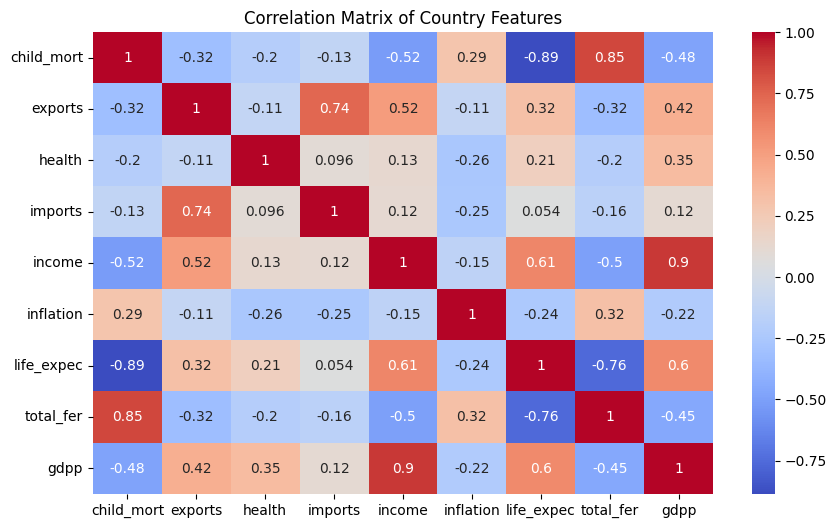

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.drop('country', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Country Features")
plt.show()

# **Correlation Insights**

**Key Observations:**

Income and GDP (gdpp) show strong positive correlation → richer countries have higher GDP per capita.
Child mortality is negatively correlated with life expectancy → higher deaths in poorer countries.
Income and child mortality are strongly negatively correlated.
Fertility rate is negatively related to income and GDP.
Health spending shows weak to moderate positive correlation with development indicators.

**Conclusion:**

The correlation matrix confirms that socio-economic indicators are strongly linked with each other and clearly differentiate developed vs underdeveloped countries.

# 9. Feature Scaling

Since K-Means is a distance-based algorithm, all features must be on the same scale.
Without scaling, features like income and gdpp would dominate clustering results.

In [9]:
from sklearn.preprocessing import StandardScaler

# Dropping country column (not needed for clustering)
X = df.drop('country', axis=1)

# Apply Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 10. Elbow Method (Optimal K Selection)
    
To find the best number of clusters (K), we use the Elbow Method.
It helps us determine the point where adding more clusters does not significantly improve the model.

In [10]:
from sklearn.cluster import KMeans

wcss = []

# Trying different values of K
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

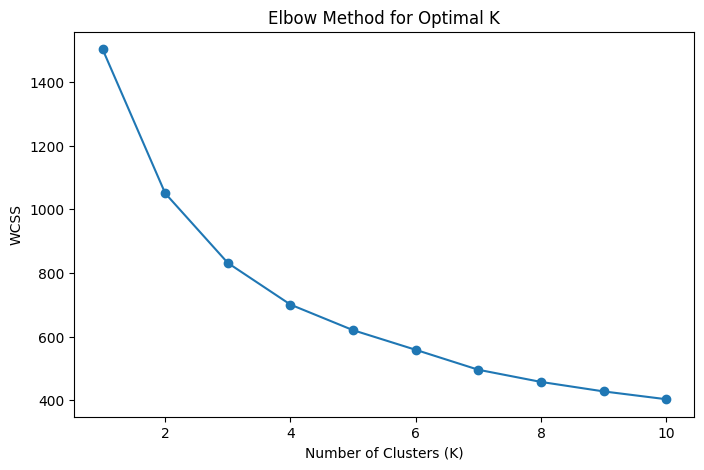

In [11]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

# Observation:
- WCSS decreases as K increases.
- After a certain point, the decrease becomes slow.
- The "elbow point" is the optimal number of clusters.
  
Based on the graph, we select K = 3 (usually for this dataset).

# 11. K-Means Model

**K-Means Clustering Model**

Based on the Elbow Method, we choose K = 3 to segment countries into 3 groups:

- Developed
- Developing
- Underdeveloped

In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [13]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


# 12. Cluster Profiling

- After generating clusters using K-Means, the average values of each feature were calculated for every cluster.

This analysis helps in understanding the characteristics of different country groups and identifying whether a cluster represents developed, developing, or underdeveloped nations.

In [14]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

         child_mort    exports    health    imports        income  inflation  \
Cluster                                                                        
0          5.000000  58.738889  8.807778  51.491667  45672.222222   2.671250   
1         92.961702  29.151277  6.388511  42.323404   3942.404255  12.019681   
2         21.927381  40.243917  6.200952  47.473404  12305.595238   7.600905   

         life_expec  total_fer          gdpp  
Cluster                                       
0         80.127778   1.752778  42494.444444  
1         59.187234   5.008085   1922.382979  
2         72.814286   2.307500   6486.452381  


# 13. Cluster Size Analysis

The number of countries present in each cluster was calculated to understand the distribution of countries across different segments.

This helps in identifying whether the clusters are balanced and suitable for further analysis.

In [15]:
print(df['Cluster'].value_counts().sort_index())

Cluster
0    36
1    47
2    84
Name: count, dtype: int64


# 14. Cluster Label Assignment

Based on the cluster profiling results, meaningful labels were assigned to each cluster.

- Developed Countries
- Developing Countries
- Underdeveloped Countries
  
These labels improve interpretability and help in understanding the socio-economic status of countries within each cluster.

In [16]:
cluster_names = {
    0: "Developed",
    1: "Underdeveloped",
    2: "Developing"
}

df["Country_Category"] = df["Cluster"].map(cluster_names)

print(df[["country", "Cluster", "Country_Category"]].head())

               country  Cluster Country_Category
0          Afghanistan        1   Underdeveloped
1              Albania        2       Developing
2              Algeria        2       Developing
3               Angola        1   Underdeveloped
4  Antigua and Barbuda        2       Developing


# 15. Train-Test Split

The dataset was divided into training and testing sets.

- 80% of the data was used for training.
- 20% of the data was used for testing.
Stratified sampling was applied to preserve the proportion of countries from each cluster in both sets.

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(["country", "Cluster", "Country_Category"], axis=1)
y = df["Cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (133, 9)
Testing Shape: (34, 9)


# **16. Random Forest Classification**

Random Forest, an ensemble learning algorithm, was trained using the generated cluster labels as the target variable.

The model consists of multiple decision trees, and the final prediction is obtained through majority voting.

Random Forest was selected because of its robustness, ability to handle non-linear relationships, and resistance to overfitting.

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



# **17. XGBoost Classification**

XGBoost (Extreme Gradient Boosting), a powerful ensemble learning algorithm, was applied to classify countries into the generated clusters.

XGBoost improves prediction performance by sequentially building decision trees and correcting errors made by previous trees.

The model was evaluated using accuracy, precision, recall, and F1-score.

In [19]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.9411764705882353

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      0.90      0.95        10
           2       0.89      1.00      0.94        17

    accuracy                           0.94        34
   macro avg       0.96      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34



# 18. DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) was applied to identify clusters based on data density.

Unlike K-Means, DBSCAN does not require the number of clusters to be specified in advance and is capable of detecting noise and outliers in the dataset.

In [20]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


# DBSCAN Cluster Analysis

The DBSCAN algorithm identified density-based clusters and detected outlier countries that did not belong to any dense region.

Noise points represent countries with socio-economic characteristics significantly different from the majority of countries in the dataset.

In [21]:
print("Number of DBSCAN Clusters:",
      len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0))

print("Number of Noise Points:",
      list(df['DBSCAN_Cluster']).count(-1))

Number of DBSCAN Clusters: 1
Number of Noise Points: 30


# DBSCAN Hyperparameter Tuning

Different values of the epsilon (eps) parameter were tested to identify the optimal density threshold for clustering.

The objective was to obtain meaningful country segments while minimizing excessive noise points.

In [22]:
from sklearn.cluster import DBSCAN

for eps in [0.8, 1.0, 1.2, 1.4]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)

    print(f"eps={eps} --> Clusters={n_clusters}, Noise={noise}")

eps=0.8 --> Clusters=3, Noise=146
eps=1.0 --> Clusters=3, Noise=94
eps=1.2 --> Clusters=3, Noise=53
eps=1.4 --> Clusters=1, Noise=40


# DBSCAN Parameter Optimization

After selecting a suitable epsilon value, different values of the min_samples parameter were evaluated.

This helped identify a density configuration that produced meaningful clusters while reducing the number of noise points.

In [23]:
for min_samples in [3, 4, 5]:
    db = DBSCAN(eps=1.2, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)

    print(f"min_samples={min_samples} --> Clusters={n_clusters}, Noise={noise}")

min_samples=3 --> Clusters=4, Noise=41
min_samples=4 --> Clusters=3, Noise=50
min_samples=5 --> Clusters=3, Noise=53


# Final DBSCAN Clustering

After hyperparameter tuning, DBSCAN was configured with:

- eps = 1.2
- min_samples = 3

The optimized model identified multiple density-based clusters and detected outlier countries with distinct socio-economic characteristics.

Compared to the initial configuration, the tuned model produced more meaningful segmentation results.

In [24]:
dbscan = DBSCAN(eps=1.2, min_samples=3)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 1    78
-1    41
 0    25
 2    19
 3     4
Name: count, dtype: int64


# 18. Model Comparison

The performance of Random Forest and XGBoost classifiers was compared using accuracy scores.

Both models were trained on the cluster labels generated through K-Means clustering. The comparison helps identify the model that best captures the characteristics of different country segments.

In [25]:
from sklearn.metrics import accuracy_score

rf_acc = accuracy_score(y_test, y_pred)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print("Random Forest Accuracy :", rf_acc)
print("XGBoost Accuracy       :", xgb_acc)

Random Forest Accuracy : 1.0
XGBoost Accuracy       : 0.9411764705882353


# 19.Feature Importance Analysis

Feature importance was evaluated using the Random Forest model to identify the most influential socio-economic indicators affecting country segmentation.

This analysis helps understand which factors contribute most to distinguishing between different country groups.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

      Feature  Importance
0  child_mort    0.258356
8        gdpp    0.197672
7   total_fer    0.174131
6  life_expec    0.166180
4      income    0.144466
2      health    0.025791
5   inflation    0.016371
3     imports    0.009472
1     exports    0.007561


# Feature Importance Visualization

A feature importance chart was generated using the Random Forest model.

The visualization highlights the relative contribution of each socio-economic indicator in determining country segments and provides interpretability to the classification model.

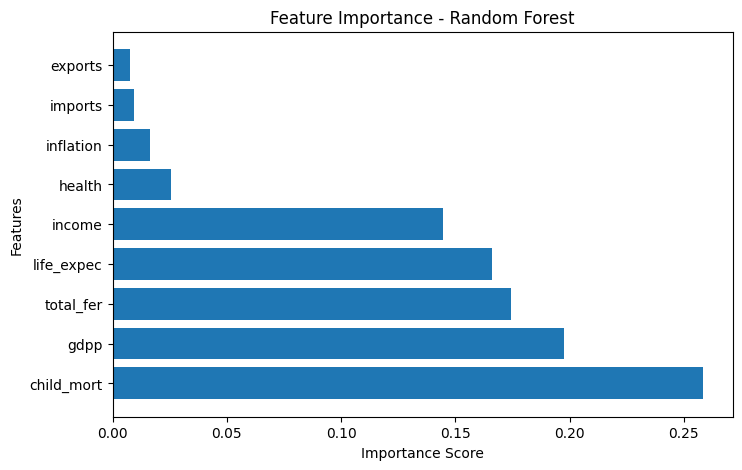

In [27]:
plt.figure(figsize=(8,5))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

# **Develop a Customer Intelligence System using Classification, Ensemble Learning & Clustering**

# 1. Data Loading and Understanding

The dataset was loaded and inspected to understand its structure, data types, and available features. Initial exploration was performed using functions such as head(), info(), and describe().

# 2. Exploratory Data Analysis (EDA)

Descriptive statistics were analyzed to understand the distribution of socio-economic indicators across countries. This helped identify variations in income, GDP, life expectancy, fertility rate, and child mortality.

# 3. Correlation Analysis

A correlation heatmap was generated to examine relationships among different features. This analysis helped identify positively and negatively correlated socio-economic indicators.

# 4. Data Preprocessing

The country column was removed because it is a categorical identifier and not useful for clustering or classification.

All numerical features were standardized using StandardScaler to ensure that variables with larger ranges did not dominate the clustering process.

# 5. K-Means Clustering

The Elbow Method was applied to determine the optimal number of clusters.

K-Means clustering was then performed with K = 3, resulting in meaningful segmentation of countries based on socio-economic characteristics.

The generated clusters represented:

- Developed Countries
- Developing Countries
- Underdeveloped Countries

# 6. Cluster Profiling
The average values of each feature were calculated for every cluster.

Cluster analysis revealed clear differences in:

- Income
- GDP per capita
- Child mortality
- Fertility rate
- Life expectancy
This helped interpret the socio-economic characteristics of each cluster.

# 7. Cluster Distribution Analysis
The number of countries in each cluster was analyzed to understand cluster balance and distribution.

Cluster counts:

- Cluster 0: 36 Countries
- Cluster 1: 47 Countries
- Cluster 2: 84 Countries

# 8. Cluster Label Assignment
Meaningful labels were assigned to the generated clusters:

- Cluster 0 → Developed
- Cluster 1 → Underdeveloped
- Cluster 2 → Developing
These labels improved interpretability and enabled supervised learning in later stages.

# 9. DBSCAN Clustering
DBSCAN was applied as a density-based clustering algorithm.

Initial results were further improved through hyperparameter tuning using different values of:

- eps
- min_samples

Final configuration:

- eps = 1.2
- min_samples = 3
The optimized DBSCAN model identified multiple density-based clusters and outlier countries.

# 10. Train-Test Split
The dataset was divided into:

- 80% Training Data
- 20% Testing Data

Stratified sampling was used to preserve cluster distribution across both datasets.

# 11. Random Forest Classification
Random Forest, an ensemble learning algorithm, was trained using the cluster labels generated by K-Means.

The model successfully learned country segmentation patterns and achieved excellent classification performance.

- Result
- Accuracy = 100%

# 12. XGBoost Classification
XGBoost was applied as a gradient boosting ensemble technique to classify countries into their respective clusters.

The model demonstrated strong predictive capability on the testing dataset.

- Result
- Accuracy = 94.12%

# 13. Model Performance Comparison
The performance of Random Forest and XGBoost was compared using accuracy scores.

| Model | Accuracy |
|------|-----|
| Random Forest | 100.00% |
| XGBoost | 94.12% |

Random Forest achieved the highest predictive performance and was selected as the best-performing model.

# 14. Feature Importance Analysis
Feature importance was extracted from the Random Forest model to identify the most influential socio-economic indicators.

Top influential features:

- Child Mortality
- GDP per Capita
- Fertility Rate
- Life Expectancy
- Income
This analysis provided insights into the key factors affecting country segmentation.

# 15. Feature Importance Visualization
A feature importance graph was generated to visually represent the contribution of each feature in classification and segmentation.

# 16. Conclusion

This project successfully implemented clustering, classification, and ensemble learning techniques to analyze and segment countries based on socio-economic indicators.

K-Means produced meaningful country segments, while DBSCAN identified density-based groups and outliers. The generated cluster labels were used to train Random Forest and XGBoost classifiers.

Random Forest achieved the highest accuracy of 100%, while XGBoost achieved 94.12% accuracy. Feature importance analysis revealed that child mortality, GDP per capita, fertility rate, life expectancy, and income were the most significant factors influencing country segmentation.

The project demonstrates how machine learning can be applied to generate intelligent segmentation and actionable insights from socio-economic data.